# ３章５節２項 船舶の物体検知

## 概要
海上船舶をディープラーニングモデルによる物体検知する実装です。


## 使用データ

| 項目 | 情報 |
| ---- | ---- | 
| 衛星 | RadarSat-2, TerraSAR-X, Sentinel-1 |
| データリンク | [Google Drive](https://drive.google.com/file/d/1glNJUGotrbEyk43twwB9556AdngJsynZ/view) |
| 画像クレジット| [*SAR Ship Detection Dataset (SSDD)*](https://www.mdpi.com/2072-4292/13/18/3690) に従う  |

## 学習済みモデル

https://drive.google.com/drive/u/0/folders/1t1KY25GVs8DsmXcsYGBTVf4yPItpXWK3

## 使用データ

| 項目 | 情報 |
| ---- | ---- | 
| 衛星 | ICEYE |
| データリンク | [Example SAR data from ICEYE](https://www.iceye.com/lp/example-spot-extended-area-dataset-japan-australia) |
| 画像クレジット| ©︎ICEYE Oy |

大変ながらくお時間をかけてしまったため、公式の ICEYE オープンデータでは、書籍の羽田空港の観測データが見つからなくなってしましました。
コード自体に問題はないので別途、海上でのサンプルをご利用ください。良いサンプルが見つかりましたら、追記したいします。


## データ展開方法

```shell
tar -xf ./Official-SSDD-OPEN.rar
```

または、GUIツールによって展開する

In [ ]:
import os
import numpy as np
import warnings
import tifffile
import cv2
from glob import glob
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.animation as animation
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
from pycocotools.coco import COCO

# pnada print options
pd.set_option('display.max_columns', 255)
pd.set_option('display.max_rows', 255)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 255)


PATH_OUTPUT = os.path.join('output', '3_5_2')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [3]:
PATH_ROOT = os.path.join('..', 'data', 'ship', 'Official-SSDD-OPEN')
PATH_BBOX = os.path.join(PATH_ROOT, 'BBox_SSDD')
PATH_SEGS = os.path.join(PATH_ROOT, 'BBox_RBox_PSeg_SSDD' ,'coco_style')

PATH_IMG  = os.path.join(PATH_SEGS, 'images')
PATH_COCO = os.path.join(PATH_SEGS, 'annotations', 'train.json')

# Load COCO annotations
coco = COCO(PATH_COCO)
cats = coco.loadCats(coco.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO Categories: {}\n'.format(' '.join(nms)))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
COCO Categories: ship



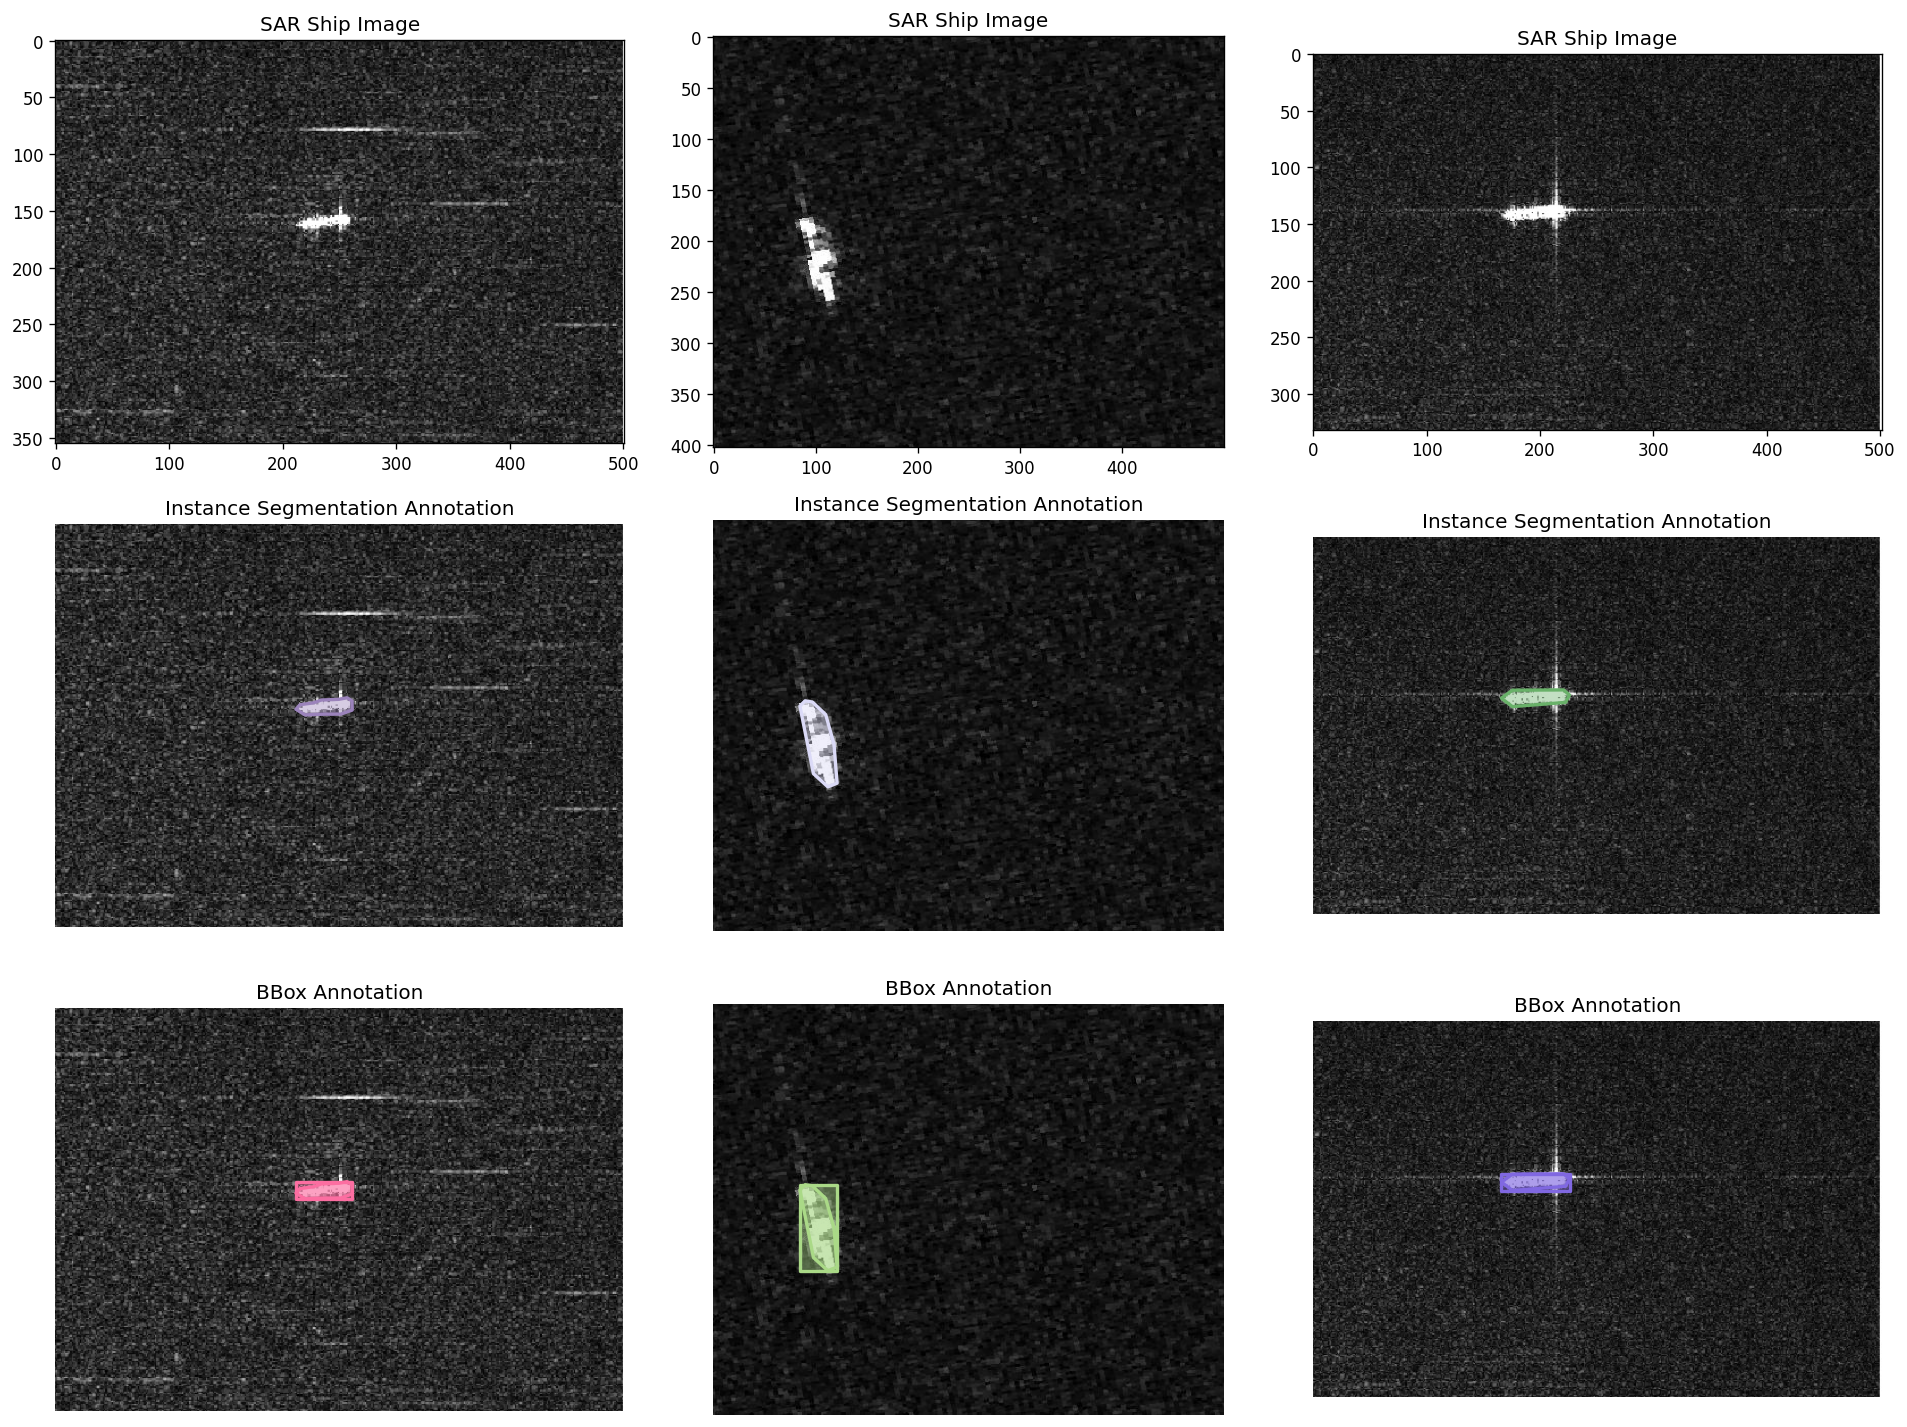

In [ ]:
NUM_IMAGE = 3

catIds = coco.getCatIds(catNms=['ship']);
imgIds = coco.getImgIds(catIds=catIds);

plt.figure(figsize=(16, 12), facecolor='white', dpi=120, edgecolor='k')
for i in range(NUM_IMAGE):
    img_info = coco.loadImgs(imgIds[i])[0]
    I = cv2.imread(f'{PATH_IMG}/train/{img_info["file_name"]}')
    plt.subplot(3, NUM_IMAGE, i+1)
    plt.title('SAR Ship Image')
    # plt.axis('off')
    plt.imshow(I)

    plt.subplot(3, NUM_IMAGE, i+1+NUM_IMAGE)
    plt.title('Instance Segmentation Annotation')
    plt.axis('off')
    plt.imshow(I)
    annIds = coco.getAnnIds(imgIds=img_info['id'], catIds=catIds, iscrowd=None)
    anns = coco.loadAnns(annIds)
    coco.showAnns(anns, draw_bbox=False)
    
    plt.subplot(3, NUM_IMAGE, i+1+NUM_IMAGE*2)
    plt.title('BBox Annotation')
    plt.axis('off')
    plt.imshow(I)
    annIds = coco.getAnnIds(imgIds=img_info['id'], catIds=catIds, iscrowd=None)
    anns = coco.loadAnns(annIds)
    coco.showAnns(anns, draw_bbox=True)

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'visualize_instance_annotation_tiles.png'), format='png')
plt.show();plt.clf();plt.close()

## mmdetection

In [27]:
# Check nvcc version
!nvcc -V
# Check GCC version
!gcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Thu_Nov_18_09:45:30_PST_2021
Cuda compilation tools, release 11.5, V11.5.119
Build cuda_11.5.r11.5/compiler.30672275_0
gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [4]:
import torch
import torchvision

print(f"PyTorch Version: {torch.__version__} | Torchvision Version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()} | Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 1.12.1+cu116 | Torchvision Version: 0.13.1+cu116
CUDA Available: True | Device: NVIDIA RTX A6000


In [3]:
import mmcv
import mmdet

print(f"MMDetection Version: {mmdet.__version__} | MMCV Version: {mmcv.__version__}")

MMDetection Version: 3.3.0 | MMCV Version: 2.0.0rc4


In [30]:
from mmengine.utils import get_git_hash
from mmengine.utils.dl_utils import collect_env as collect_base_env

import mmdet


def collect_env():
    """Collect the information of the running environments."""
    env_info = collect_base_env()
    env_info['MMDetection'] = f'{mmdet.__version__}+{get_git_hash()[:7]}'
    return env_info


if __name__ == '__main__':
    for name, val in collect_env().items():
        print(f'{name}: {val}')

sys.platform: linux
Python: 3.10.14 (main, Mar 21 2024, 16:24:04) [GCC 11.2.0]
CUDA available: True
MUSA available: False
numpy_random_seed: 587304293
GPU 0: NVIDIA RTX A6000
CUDA_HOME: /usr
NVCC: Cuda compilation tools, release 11.5, V11.5.119
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
PyTorch: 1.12.1+cu116
PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201402
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.6.0 (Git Hash 52b5f107dd9cf10910aaa19cb47f3abf9b349815)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.6
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_

## Train 

model: ![RTMDet](https://user-images.githubusercontent.com/27466624/225922103-404064c1-3cb0-4ab5-9388-79f9517dcdb0.jpg)


In [40]:
config_ship_bbox = """
# Inherit and overwrite part of the config based on this config
_base_ = './rtmdet_tiny_8xb32-300e_coco.py'

data_root = '../data/ship/Official-SSDD-OPEN/BBox_RBox_PSeg_SSDD/coco_style' # dataset root

train_batch_size_per_gpu = 16
train_num_workers = 1

max_epochs = 20
stage2_num_epochs = 1
base_lr = 0.00008

metainfo = {
    'classes': ('ship', ),
    'palette': [
        (20, 60, 220),
    ]
}

train_dataloader = dict(
    batch_size=train_batch_size_per_gpu,
    num_workers=train_num_workers,
    dataset=dict(
        data_root=data_root,
        metainfo=metainfo,
        data_prefix=dict(img='images/train/'),
        ann_file='annotations/train.json'))

val_dataloader = dict(
    dataset=dict(
        data_root=data_root,
        metainfo=metainfo,
        data_prefix=dict(img='images/test/'),
        ann_file='annotations/test.json'))

test_dataloader = val_dataloader
val_evaluator = dict(ann_file=data_root + '/annotations/test.json')
test_evaluator = val_evaluator

model = dict(bbox_head=dict(num_classes=1))

# learning rate
param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=1.0e-5,
        by_epoch=False,
        begin=0,
        end=10),
    dict(
        # use cosine lr from 10 to 20 epoch
        type='CosineAnnealingLR',
        eta_min=base_lr * 0.05,
        begin=max_epochs // 2,
        end=max_epochs,
        T_max=max_epochs // 2,
        by_epoch=True,
        convert_to_iter_based=True),
]

train_pipeline_stage2 = [
    dict(type='LoadImageFromFile', backend_args=None),
    dict(type='LoadAnnotations', with_bbox=True),
    dict(
        type='RandomResize',
        scale=(640, 640),
        ratio_range=(0.5, 2.0),
        keep_ratio=True),
    dict(type='RandomCrop', crop_size=(640, 640)),
    dict(type='YOLOXHSVRandomAug'),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(640, 640), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

# optimizer
optim_wrapper = dict(
    _delete_=True,
    type='OptimWrapper',
    optimizer=dict(type='AdamW', lr=base_lr, weight_decay=0.05),
    paramwise_cfg=dict(
        norm_decay_mult=0, bias_decay_mult=0, bypass_duplicate=True))

    
default_hooks = dict(
    timer=dict(type='IterTimerHook'),
    logger=dict(type='LoggerHook', interval=10),
    param_scheduler=dict(type='ParamSchedulerHook'),
    checkpoint=dict(type='CheckpointHook', 
        interval=5,
        max_keep_ckpts=1,  # only keep latest 1 checkpoints
        save_best='auto'
    ),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    visualization=dict(type='DetVisualizationHook',
        draw=True, show=False, interval=5,
    ),
)

custom_hooks = [
    dict(
        type='PipelineSwitchHook',
        switch_epoch=max_epochs - stage2_num_epochs,
        switch_pipeline=train_pipeline_stage2)
]

# load COCO pre-trained weight
load_from = 'https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth'

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=max_epochs, val_interval=1)
visualizer = dict(type='DetLocalVisualizer',
    vis_backends=[
        dict(type='LocalVisBackend'),
        dict(type='TensorboardVisBackend'),
    ],
    name='visualizer',
)

"""

with open(f'mmdetection/configs/rtmdet/rtmdet_tiny_ship_bbox.py', 'w') as f:
    f.write(config_ship_bbox)
    
config_ship_segm = """
# Inherit and overwrite part of the config based on this config
_base_ = './rtmdet-ins_tiny_8xb32-300e_coco.py'

data_root = '../data/ship/Official-SSDD-OPEN/BBox_RBox_PSeg_SSDD/coco_style' # dataset root

train_batch_size_per_gpu = 16
train_num_workers = 1

max_epochs = 20
stage2_num_epochs = 1
base_lr = 0.00008

metainfo = {
    'classes': ('ship', ),
    'palette': [
        (20, 60, 220),
    ]
}

train_dataloader = dict(
    batch_size=train_batch_size_per_gpu,
    num_workers=train_num_workers,
    dataset=dict(
        data_root=data_root,
        metainfo=metainfo,
        data_prefix=dict(img='images/train/'),
        ann_file='annotations/train.json'))

val_dataloader = dict(
    dataset=dict(
        data_root=data_root,
        metainfo=metainfo,
        data_prefix=dict(img='images/test/'),
        ann_file='annotations/test.json'))

test_dataloader = val_dataloader
val_evaluator = dict(ann_file=data_root + '/annotations/test.json')
test_evaluator = val_evaluator

model = dict(bbox_head=dict(num_classes=1))

# learning rate
param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=1.0e-5,
        by_epoch=False,
        begin=0,
        end=10),
    dict(
        # use cosine lr from 10 to 20 epoch
        type='CosineAnnealingLR',
        eta_min=base_lr * 0.05,
        begin=max_epochs // 2,
        end=max_epochs,
        T_max=max_epochs // 2,
        by_epoch=True,
        convert_to_iter_based=True),
]

train_pipeline_stage2 = [
    dict(type='LoadImageFromFile', backend_args=None),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True,),
    dict(
        type='RandomResize',
        scale=(640, 640),
        ratio_range=(0.5, 2.0),
        keep_ratio=True),
    dict(type='RandomCrop', crop_size=(640, 640)),
    dict(type='YOLOXHSVRandomAug'),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(640, 640), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

# optimizer
optim_wrapper = dict(
    _delete_=True,
    type='OptimWrapper',
    optimizer=dict(type='AdamW', lr=base_lr, weight_decay=0.05),
    paramwise_cfg=dict(
        norm_decay_mult=0, bias_decay_mult=0, bypass_duplicate=True))

    
default_hooks = dict(
    timer=dict(type='IterTimerHook'),
    logger=dict(type='LoggerHook', interval=10),
    param_scheduler=dict(type='ParamSchedulerHook'),
    checkpoint=dict(type='CheckpointHook', 
        interval=5,
        max_keep_ckpts=1,  # only keep latest 1 checkpoints
        save_best='auto'
    ),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    visualization=dict(type='DetVisualizationHook',
        draw=True, show=False, interval=5,
    ),
)

custom_hooks = [
    dict(
        type='PipelineSwitchHook',
        switch_epoch=max_epochs - stage2_num_epochs,
        switch_pipeline=train_pipeline_stage2)
]

# load COCO pre-trained weight
load_from = 'https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet-ins_tiny_8xb32-300e_coco/rtmdet-ins_tiny_8xb32-300e_coco_20221130_151727-ec670f7e.pth'

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=max_epochs, val_interval=1)
visualizer = dict(type='DetLocalVisualizer',
    vis_backends=[
        dict(type='LocalVisBackend'),
        dict(type='TensorboardVisBackend'),
    ],
    name='visualizer',
)

"""

with open(f'mmdetection/configs/rtmdet/rtmdet_tiny_ship_segm.py', 'w') as f:
    f.write(config_ship_segm)

### Example

Run Train Sehll Script
```shell
python tools/train.py configs/rtmdet/rtmdet_tiny_ship_segm.py
```


In [41]:
!python mmdetection/tools/train.py mmdetection/configs/rtmdet/rtmdet_tiny_ship_bbox.py \
    --work-dir {PATH_OUTPUT}/work_dir/rtmdet_tiny_bbox/

/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
11/11 15:25:49 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.14 (main, Mar 21 2024, 16:24:04) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 375595150
    GPU 0: NVIDIA RTX A6000
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 11.5, V11.5.119
    GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 1.12.1+cu116
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201402
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 archit

In [42]:
!python mmdetection/tools/train.py mmdetection/configs/rtmdet/rtmdet_tiny_ship_segm.py \
    --work-dir {PATH_OUTPUT}/work_dir/rtmdet_tiny_segm/

/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
11/11 15:37:42 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.14 (main, Mar 21 2024, 16:24:04) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 38769579
    GPU 0: NVIDIA RTX A6000
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 11.5, V11.5.119
    GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 1.12.1+cu116
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201402
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 archite

## Logs 

Tensorboard View

In [ ]:
# load tensorboard in colab
%load_ext tensorboard

# see curves in tensorboard
%tensorboard --logdir {PATH_OUTPUT}/work_dir/

Launching TensorBoard...

## Inference

In [ ]:
!python mmdetection/demo/large_image_demo.py \
    mmdetection/demo/large_image.jpg \
    output/206/work_dir/rtmdet_tiny_segm/rtmdet_tiny_ship_segm.py \
    {PATH_OUTPUT}/work_dir/rtmdet_tiny_segm/best_coco_bbox_mAP_epoch_5.pth

/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Loads checkpoint by local backend from path: output/206/work_dir/rtmdet_tiny_segm/best_coco_bbox_mAP_epoch_60.pth
/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.TensorboardVisBackend'>, please provide the `save_dir` argument.
  warnings.wa

Output()

Loads checkpoint by local backend from path: output/206/work_dir/rtmdet_tiny_segm/best_coco_bbox_mAP_epoch_20.pth


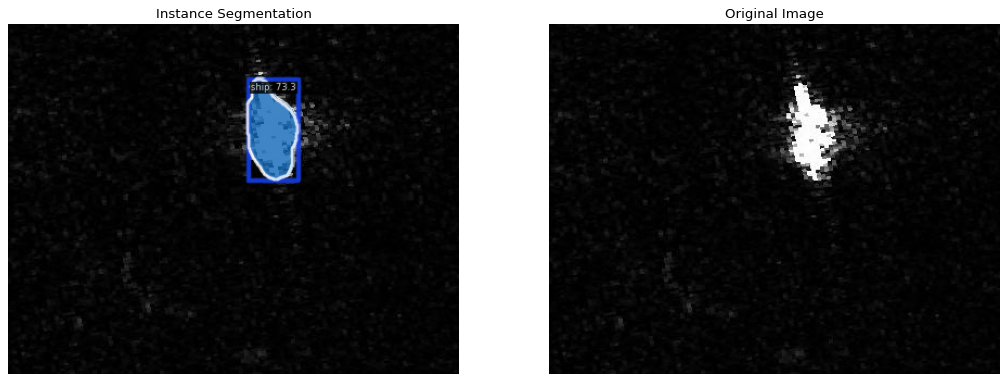

In [44]:
from mmdet.apis import DetInferencer
from glob import glob

# Choose to use a config
config = f'{PATH_OUTPUT}/work_dir/rtmdet_tiny_segm/rtmdet_tiny_ship_segm.py'
# Setup a checkpoint file to load
checkpoint = glob(f'{PATH_OUTPUT}/work_dir/rtmdet_tiny_segm/best_*.pth')[0]

# Set the device to be used for evaluation
device = 'cuda:0'

# Initialize the DetInferencer
inferencer = DetInferencer(config, checkpoint, device)

# Use the detector to do inference
img = f'{PATH_IMG}/test/000001.jpg'
result = inferencer(img, out_dir=f'{PATH_OUTPUT}/inference')

img_draw = result["visualization"][0]
plt.figure(figsize=(16, 6), facecolor='white', dpi=80, edgecolor='k')
plt.subplot(1, 2, 1)
plt.title('Instance Segmentation')
plt.imshow(img_draw)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Original Image')
img = cv2.imread(img)
plt.imshow(img)
plt.axis('off')
plt.show();plt.clf();plt.close()

## 未学習の衛星データによる推論

ICEYE の衛星データを使用します。

In [ ]:
PATH_ICEYE = os.path.join('..', 'data', 'ship', 'iceye')
PATH_TIF   = os.path.join(PATH_ICEYE, 'ICEYE_GRD_SLEA_185384_20211126T051656.tif')

img = tifffile.imread(PATH_TIF)
img.shape, img.dtype

((31958, 31168), dtype('uint16'))

In [ ]:

img_dB = 10 * np.log10(img + 1e-1)

# plot
plt.figure(figsize=(16, 10), facecolor='white', dpi=120, edgecolor='k')
plt.subplot(1, 2, 1)
plt.title('Amplitude Image')
plt.imshow(img, cmap='gray', vmax=225, vmin=4)
plt.colorbar(shrink=0.5)

plt.subplot(1, 2, 2)
plt.title('dB Image')
plt.imshow(img_dB, cmap='gray', vmin=10, vmax=30)
plt.colorbar(shrink=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'iceye_amplitude_dB.png'), format='png')
plt.show();plt.clf();plt.close()

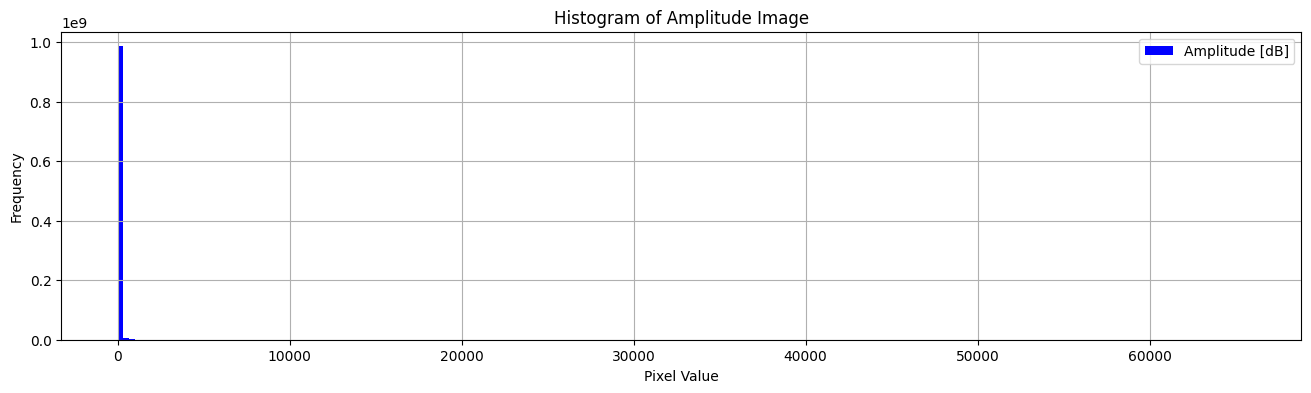

In [62]:
# histogram
plt.figure(figsize=(16, 4), facecolor='white', dpi=100, edgecolor='k')
plt.hist(img.flatten(), bins=200, color='blue',label='Amplitude')
plt.title('Histogram of Amplitude Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.savefig(f'{PATH_OUTPUT}/iceye_histogram.png', format='png')
plt.show();plt.clf();plt.close()


In [ ]:
AOI_PIXELS = (slice(23000, 30000), slice(20000, 29000))

img_amp_aoi = img[AOI_PIXELS]

P_L = 2
P_H = 98

# percentile
p_low = np.percentile(img, P_L)
p_high = np.percentile(img, P_H)
print(f'Percentile {P_L}: {p_low:.2f}, Percentile {P_H}: {p_high:.2f}')

# normalize
img_amp_aoi_norm = (img_amp_aoi - p_low) / (p_high - p_low)
img_amp_aoi_norm = np.clip(img_amp_aoi_norm, 0, 1)

# plot
plt.figure(figsize=(14, 10), facecolor='white', dpi=120, edgecolor='k')
plt.imshow(img_amp_aoi_norm, cmap='gray', vmin=0, vmax=1)
plt.colorbar(shrink=0.5)
plt.title('Normalized dB Image')
plt.axis('off')
plt.savefig(f'{PATH_OUTPUT}/iceye_normalized_dB.png', format='png')
plt.show();plt.clf();plt.close()

img_8bit = (img_amp_aoi_norm * 255).astype(np.uint8)
img_8bit = np.stack([img_8bit] * 3, axis=-1)
cv2.imwrite(os.path.join(PATH_OUTPUT, 'iceye_input.png' ), img_8bit)

In [67]:
!python mmdetection/demo/large_image_demo.py \
    {PATH_OUTPUT}/iceye_input.png --score-thr 0.5 --patch-size 1920 \
    output/206/work_dir/rtmdet_tiny_bbox/rtmdet_tiny_ship_bbox.py \
    {PATH_OUTPUT}/work_dir/rtmdet_tiny_bbox/best_coco_bbox_mAP_epoch_20.pth \
    --out-dir {PATH_OUTPUT}/inference_iceye/

/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Loads checkpoint by local backend from path: output/206/work_dir/rtmdet_tiny_bbox/best_coco_bbox_mAP_epoch_20.pth
/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/home/ss/anaconda3/envs/sar-book/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.TensorboardVisBackend'>, please provide the `save_dir` argument.
  warnings.wa

In [ ]:
img_pred = cv2.imread(os.path.join(PATH_OUTPUT, 'inference_iceye/iceye_input.png'))
plt.figure(figsize=(16, 10), facecolor='white', dpi=120, edgecolor='k')
plt.imshow(img_pred)
plt.axis('off')
plt.show();plt.clf();plt.close()